<a href="https://colab.research.google.com/github/PriceyMS/CUSTOMER-SEGMENTATION-USING-KMEANS-CLUSTERING/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing  Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

Loading Data and Exploratory Data Analysis

In [4]:
#loading data from csv file to pandas dataframe
customer_data= pd.read_csv('/content/Mall_Customers.csv')

In [5]:
#viewing first five rows
customer_data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
customer_data.shape

(200, 5)

In [7]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
#checking for null values
customer_data.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Clustering

In [9]:
#For the clusters, columns Annual Income and spending income are selected
x = customer_data.iloc[:,[3,4]].values


In [10]:
#finding wcss values for different number of clusters

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)


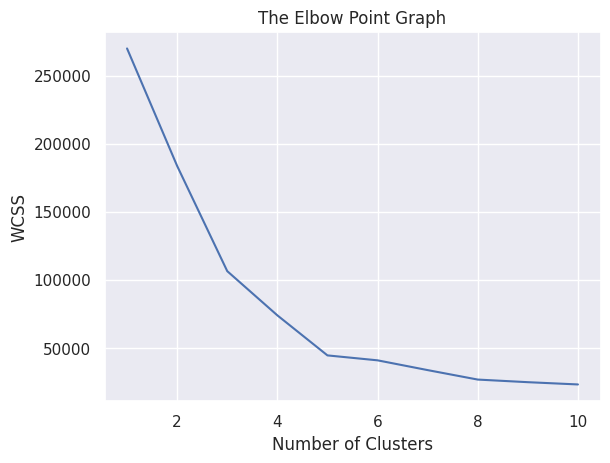

In [11]:
#plotting an elbow graph to identify number of clusters to use
sns.set()
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

Hence; Optimum number of clusters is 5

Training the Kmeans clustering model

In [13]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)

# Return label for each point based on the cluster
y = kmeans.fit_predict(x)

print(y)


[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


Visualizing the clusters

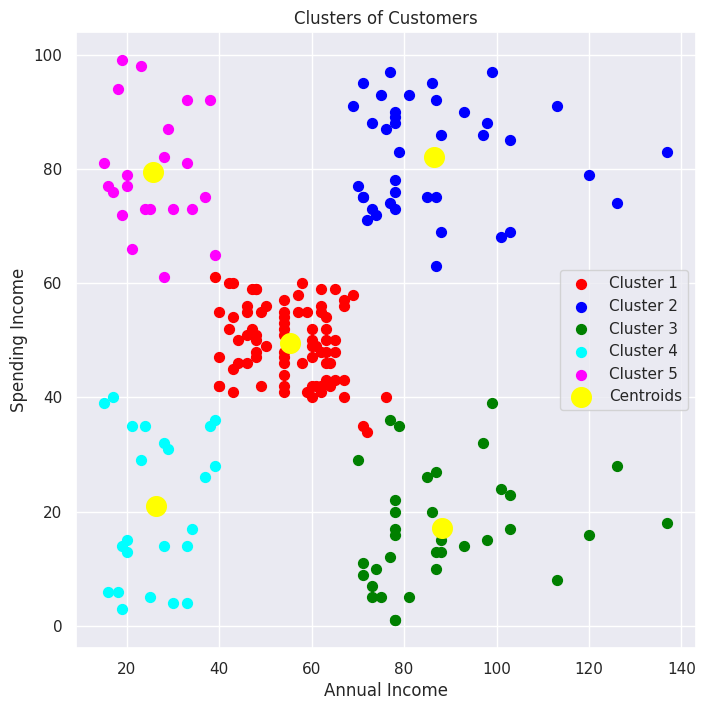

In [16]:
plt.figure(figsize=(8, 8))

plt.scatter(x[y == 0, 0], x[y == 0, 1], s=50, c='red', label='Cluster 1')
plt.scatter(x[y == 1, 0], x[y == 1, 1], s=50, c='blue', label='Cluster 2')
plt.scatter(x[y == 2, 0], x[y == 2, 1], s=50, c='green', label='Cluster 3')
plt.scatter(x[y == 3, 0], x[y == 3, 1], s=50, c='cyan', label='Cluster 4')
plt.scatter(x[y == 4, 0], x[y == 4, 1], s=50, c='magenta', label='Cluster 5')

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c='yellow',
    label='Centroids'
)

plt.title('Clusters of Customers')
plt.xlabel('Annual Income')
plt.ylabel('Spending Income')
plt.legend()
plt.show()


**Cluster-Wise Interpretation**


Cluster 1;
 represents customers with moderate annual income and moderate spending behavior, forming a stable customer base that contributes consistently to overall revenue and responds well to standard marketing and loyalty programs.


Cluster 2;
 consists of high-income customers with high spending scores, indicating a premium segment that generates significant revenue and is best targeted with personalized, high-value offers and exclusive products.

Cluster 3;
 includes customers with high income but low spending behavior, suggesting untapped purchasing potential that could be activated through targeted engagement strategies and value-driven incentives.

Cluster 4;
 is characterized by low-income customers with low spending scores, a highly price-sensitive segment for which cost-effective promotions and essential product offerings are most appropriate.

Cluster 5;
 comprises customers with relatively low income but high spending behavior, indicating strong engagement or impulsive purchasing patterns, making them valuable in the short term but potentially higher risk in terms of long-term sustainability.